In [1]:
print("Hello World")

Hello World


In [2]:

import numpy as np
import requests
import matplotlib.pyplot as plt


from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.nn import functional as F

In [3]:
!pip install tiktoken
import tiktoken
tokenizer = tiktoken.get_encoding('cl100k_base')


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [4]:
seq_len = 8
stride = 2
embed_dim = 2**6 
batch_size = 5

In [5]:
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tmTokens = torch.tensor( tokenizer.encode(text) )
len(tmTokens)

43053

In [6]:
class tokenDataset(Dataset):
  def __init__(self, tokens, seq_len=8, stride=4):
    self.inputs  = []
    self.targets = []
    for i in range(0,len(tokens)-seq_len,stride):
      self.inputs.append( tokens[i   : i+seq_len])
      self.targets.append(tokens[i+1 : i+seq_len+1])

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, idx):
    return self.inputs[idx], self.targets[idx]
token_dataset = tokenDataset(tmTokens,seq_len,stride)

token_dataset[4]

(tensor([ 9745,    38,   469, 37725,   220,  1758, 17601,   881]),
 tensor([   38,   469, 37725,   220,  1758, 17601,   881,  8731]))

In [7]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()
    self.embedding = nn.Embedding(tokenizer.n_vocab,embed_dim)
    self.positions = nn.Embedding(seq_len,embed_dim) 
    self.gelu = nn.GELU()
    self.layernorm  = nn.LayerNorm(embed_dim) 
    self.finalLinear = nn.Linear(embed_dim,tokenizer.n_vocab,bias=False)
    self.finalLinear.weight = nn.Parameter(self.embedding.weight) 



  def forward(self,tokx):
    token_embed = self.embedding(tokx)
    posit_embed = self.positions(torch.arange(tokx.shape[-1])) 
    x = token_embed + posit_embed 
    x = self.layernorm(x) 
    x = self.gelu(x) 
    x = self.finalLinear(x) / np.sqrt(embed_dim)
    return x

  def generate(self,tokx,temperature=1,n_new_tokens=50): 
    for _ in range(n_new_tokens):
      x = self(tokx[:,-seq_len:])
      x = x[:,-1,:] 
      probs = F.softmax(x/temperature,dim=-1) 
      tokx_next = torch.multinomial(probs,num_samples=1)
      tokx = torch.cat( (tokx,tokx_next),dim=1) # [batch, (
    return tokx

In [8]:

m = Model()
X,y = token_dataset[4]
out = m(X)

print(X.shape)
print(y.shape)
print(out.shape)

torch.Size([8])
torch.Size([8])
torch.Size([8, 100277])


In [9]:
print(f'Expected loss for random weights: {-np.log(1/tokenizer.n_vocab):.3f}')
print(f'Observed mean log-softmax output: {torch.mean(-F.log_softmax(out.detach(),dim=-1)):.3f}')
print(f'Cross-entropy loss from pytorch:  {F.cross_entropy(out.view(-1, out.shape[-1]), y.view(-1)):.3f}')

Expected loss for random weights: 11.516
Observed mean log-softmax output: 11.730
Cross-entropy loss from pytorch:  11.602


In [10]:

T = torch.ones(2,3,4) 
P = torch.arange(4)

print(f'Token embeddings matrix ({T.shape}):')
print(T)

print(f'\nPosition embeddings matrix ({P.shape}):')
print(P)

print(f'\nTheir sum: ({(T+P).shape}):')
print(T+P)

Token embeddings matrix (torch.Size([2, 3, 4])):
tensor([[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]])

Position embeddings matrix (torch.Size([4])):
tensor([0, 1, 2, 3])

Their sum: (torch.Size([2, 3, 4])):
tensor([[[1., 2., 3., 4.],
         [1., 2., 3., 4.],
         [1., 2., 3., 4.]],

        [[1., 2., 3., 4.],
         [1., 2., 3., 4.],
         [1., 2., 3., 4.]]])


In [11]:

P = m.positions(torch.arange(seq_len))
T = m.embedding(X)

print(f'Token embeddings matrix ({T.shape})')
print(f'\nPosition embeddings matrix ({P.shape})')
print(f'\nTheir sum: ({(T+P).shape})')

Token embeddings matrix (torch.Size([8, 64]))

Position embeddings matrix (torch.Size([8, 64]))

Their sum: (torch.Size([8, 64]))


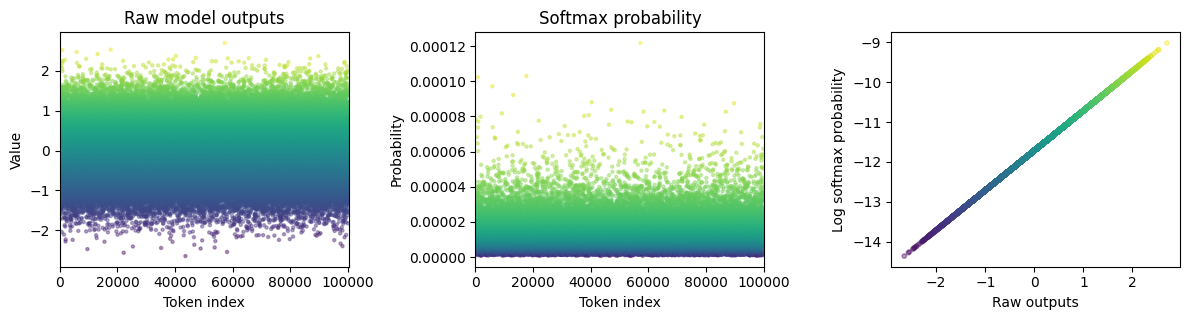

In [12]:

out = m(X)
final = out[-1,:].detach()
softmaxFinal = torch.exp(final) / torch.exp(final).sum()


_,axs = plt.subplots(1,3,figsize=(12,3.3))

axs[0].scatter(range(len(final)),final,s=5,marker='o',c=final,alpha=.4)
axs[0].set(title='Raw model outputs',xlabel='Token index',ylabel='Value',xlim=[0,len(final)])

axs[1].scatter(range(len(final)),softmaxFinal,s=5,marker='o',c=final,alpha=.4)
axs[1].set(title='Softmax probability',xlabel='Token index',ylabel='Probability',xlim=[0,len(final)])

axs[2].scatter(final,torch.log(softmaxFinal),s=10,marker='o',c=final,alpha=.4)
axs[2].set(xlabel='Raw outputs',ylabel='Log softmax probability')

plt.tight_layout()
plt.show()

In [13]:
dataloader = DataLoader(
                token_dataset,
                batch_size = batch_size,
                shuffle    = True,
                drop_last  = True
            )

X,y = next(iter(dataloader))
print(f'Inputs ({batch_size} batches X {seq_len} tokens):')
print(X)

Inputs (5 batches X 8 tokens):
tensor([[ 4920,   757,    13,   358, 15753,   389, 44517,   398],
        [80790,  1523,   279,  1317, 21765,   311,   319, 26301],
        [  319, 88172,   315,   279,  3805,   810, 19428,    13],
        [ 1375,   492,   813,   319,    66, 52384,   927,   279],
        [22169,   311,   319, 27963,  1268,   814,  2011,  2736]])


In [14]:
out = m(X)
print(out.shape)
print(out)
     
gen_tokens = m.generate(X,temperature=1.3,n_new_tokens=8)
print(gen_tokens.shape) 
     
for batchtok in gen_tokens:
  print('\n--- NEXT SAMPLE: ---\n')
  print(tokenizer.decode(batchtok.tolist()))

torch.Size([5, 8, 100277])
tensor([[[-0.7324, -0.1737,  0.1396,  ..., -0.5049, -0.9469, -0.2885],
         [ 0.3763,  0.6657, -0.0498,  ...,  0.2712,  0.3994,  0.0443],
         [-0.4950,  0.1780,  1.4210,  ..., -0.2765,  0.5931,  0.2371],
         ...,
         [ 0.2006, -0.3450,  0.2381,  ..., -0.8931, -0.3389, -0.4999],
         [-1.5644,  0.2434, -0.5165,  ..., -0.2973, -1.3420, -0.5605],
         [-0.2181, -0.1454,  0.2024,  ..., -0.5491, -0.3835, -0.1393]],

        [[-0.4062, -0.1776,  0.4463,  ..., -1.0384, -0.4583,  0.9089],
         [-0.3058,  1.3464,  0.2205,  ...,  0.5456,  0.2154,  0.2440],
         [-1.0137,  0.9826,  0.9183,  ..., -0.1890,  0.6202,  0.2456],
         ...,
         [-0.0888, -0.4493,  0.5163,  ..., -0.1561,  0.6304, -0.1371],
         [-0.3929,  0.5662,  1.5906,  ...,  0.0464,  0.3191,  0.8204],
         [-0.3590, -0.1029,  0.2647,  ...,  0.0323,  0.4890, -0.0654]],

        [[-0.4881,  0.2143,  1.0164,  ...,  0.2082,  0.3007,  0.8129],
         [-0.5673,